<a href="https://colab.research.google.com/github/soleildayana/Apophis-Asteroid-Project/blob/main/analisis/nb01_AnalisisOrbitalconIncertidumbre.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%pip install pymcel -Uq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 46.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 42.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 25.6 MB/s eta 0:00:00


In [24]:
import pymcel as pc
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Determinación de Órbita con Incertidumbre


In [6]:
# URL del archivo CSV en crudo (raw)
url = 'https://raw.githubusercontent.com/soleildayana/Apophis-Asteroid-Project/main/analisis/observaciones_astrometricas.csv'

# Importar el archivo CSV
observations_df = pd.read_csv(url)

# Mostrar las primeras filas para inspección inicial
display(observations_df)

,object_key,object_name,object_type,horizons_id,datetime_utc,datetime_tdb,t_jd_tdb,ra_deg,dec_deg,rho_au,sigma_ra_arcsec,sigma_dec_arcsec,sigma_rho_au,earth_x_au,earth_y_au,earth_z_au
0,oumuamua,1I/'Oumuamua,interestelar,1I,2017-10-19 23:58:50.818,A.D. 2017-Oct-20 00:00:00.0000,2458046.5,20.270964,3.103206,0.245243,0.8,0.8,0.00004,0.890823,0.445095,-0.000025
1,oumuamua,1I/'Oumuamua,interestelar,1I,2017-10-20 23:58:50.818,A.D. 2017-Oct-21 00:00:00.0000,2458047.5,15.433589,3.571600,0.272808,0.8,0.8,0.00004,0.882716,0.460360,-0.000026
2,oumuamua,1I/'Oumuamua,interestelar,1I,2017-10-21 23:58:50.818,A.D. 2017-Oct-22 00:00:00.0000,2458048.5,11.509500,3.936825,0.302073,0.8,0.8,0.00004,0.874344,0.475485,-0.000027
3,oumuamua,1I/'Oumuamua,interestelar,1I,2017-10-22 23:58:50.818,A.D. 2017-Oct-23 00:00:00.0000,2458049.5,8.296589,4.226159,0.332618,0.8,0.8,0.00004,0.865708,0.490467,-0.000027
4,oumuamua,1I/'Oumuamua,interestelar,1I,2017-10-23 23:58:50.818,A.D. 2017-Oct-24 00:00:00.0000,2458050.5,5.638788,4.459586,0.364148,0.8,0.8,0.00004,0.856812,0.505300,-0.000027
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,apophis,99942 Apophis,NEO,99942,2021-03-17 23:58:50.814,A.D. 2021-Mar-18 00:00:00.0000,2459291.5,130.478219,1.907592,0.119196,0.5,0.5,0.00002,-0.994165,0.046440,0.000002
107,apophis,99942 Apophis,NEO,99942,2021-03-18 11:58:50.814,A.D. 2021-Mar-18 12:00:00.0000,2459292.0,130.113779,2.283574,0.119702,0.5,0.5,0.00002,-0.994667,0.037811,0.000002
108,apophis,99942 Apophis,NEO,99942,2021-03-18 23:58:50.814,A.D. 2021-Mar-19 00:00:00.0000,2459292.5,129.758124,2.656119,0.120222,0.5,0.5,0.00002,-0.995094,0.029180,0.000002
109,apophis,99942 Apophis,NEO,99942,2021-03-19 11:58:50.814,A.D. 2021-Mar-19 12:00:00.0000,2459293.0,129.411211,3.025119,0.120754,0.5,0.5,0.00002,-0.995446,0.020546,0.000002


In [7]:
# Listar los objetos disponibles en el archivo para decidir cuál procesar
print("Objetos en el dataset:", observations_df['object_name'].unique())

# Filtrar para trabajar solo con Apophis
target_object = 'apophis'
df_target = observations_df[observations_df['object_key'] == target_object].copy()

print(f"\nProcesando únicamente el objeto: {target_object}")
print(f"Número de observaciones para este objeto: {len(df_target)}")

Objetos en el dataset: ["1I/'Oumuamua" '2I/Borisov' '1P/Halley' '99942 Apophis']

Procesando únicamente el objeto: apophis
Número de observaciones para este objeto: 39


### Re-cálculo de estado orbital para el objeto seleccionado
Ahora que hemos filtrado los datos, repetiremos el proceso de selección de época y cálculo de velocidad asegurándonos de que los índices correspondan únicamente a la serie temporal de este objeto.

## De observaciones a posiciones

Las observaciones entregan una dirección en el cielo, dada por ascensión recta y declinación, y una
distancia a la Tierra. Antes de usar esos datos en el problema de dos cuerpos, vale la pena preguntarse:



* **¿Respecto a quién están medidas las observaciones originales?**
  Las observaciones originales (RA, Dec y $\rho$) están medidas respecto a la **Tierra** (sistema geocéntrico o topocéntrico).

* **¿Respecto a quién queremos describir la órbita?**
  Queremos describir la órbita respecto al **Sol** (sistema heliocéntrico), ya que es el cuerpo dominante que determina la dinámica del sistema en el problema de dos cuerpos.

* **¿En qué sistema de referencia conviene trabajar para que las posiciones de la Tierra, del objeto y del Sol sean comparables?**
  Conviene trabajar en un sistema de coordenadas **Eclípticas Heliocéntricas** o **Ecuatoriales Heliocéntricas** (como J2000). Esto permite que el vector de posición del objeto sea simplemente la suma del vector Tierra-Sol y el vector Tierra-Objeto.

* **¿Qué transformación de coordenadas necesitan hacer para pasar de una dirección en el cielo a un vector de posición útil?**
  Se debe realizar una transformación de coordenadas esféricas a cartesianas:
  1. Convertir $(\alpha, \delta, \rho)$ a componentes $(x, y, z)$ geocéntricas usando:
  
     $x = \rho \cos(\delta) \cos(\alpha)$

     $y = \rho \cos(\delta) \sin(\alpha)$

     $z = \rho \sin(\delta)$

  2. Sumar el vector de posición de la Tierra respecto al Sol ($R_{\oplus}$) para obtener el vector de posición heliocéntrico del objeto ($r = R_{\oplus} + \rho$).

In [8]:
# 1. Selección de Época Central específica para este objeto
idx_target = len(df_target) // 2
epoch_target = 2451544.5 # J2000

# 2. Posición (r0) heliocéntrica
# Nota: r = R_earth + rho (vectorialmente)
# El archivo ya provee earth_x, y, z y rho_au, ra, dec.
# En pasos previos usamos earth_x,y,z directamente, pero esos suelen ser la posición de la Tierra.
# Para el objeto: r_obj = R_earth + rho_vec

def get_helio_pos(row):
    alpha = np.radians(row['ra_deg'])
    delta = np.radians(row['dec_deg'])
    rho = row['rho_au']

    # Vector Tierra -> Objeto (geocéntrico)
    rho_vec = np.array([
        rho * np.cos(delta) * np.cos(alpha),
        rho * np.cos(delta) * np.sin(alpha),
        rho * np.sin(delta)
    ])

    # Vector Sol -> Tierra
    R_earth = np.array([row['earth_x_au'], row['earth_y_au'], row['earth_z_au']])

    # Vector Sol -> Objeto (heliocéntrico)
    return R_earth + rho_vec

r0_obj = get_helio_pos(df_target.iloc[idx_target])

# 3. Velocidad mediante diferencias finitas sobre el objeto filtrado
dt_target = df_target.iloc[idx_target+1]['t_jd_tdb'] - df_target.iloc[idx_target-1]['t_jd_tdb']
r_next_obj = get_helio_pos(df_target.iloc[idx_target+1])
r_prev_obj = get_helio_pos(df_target.iloc[idx_target-1])

v0_obj = (r_next_obj - r_prev_obj) / dt_target

print(f"Objeto: {target_object}")
print(f"r0 heliocéntrico: {r0_obj}")
print(f"v0 heliocéntrico: {v0_obj}")

Objeto: apophis
r0 heliocéntrico: [-1.06055157  0.25244044 -0.00799661]
v0 heliocéntrico: [-0.00238283 -0.01519556  0.00157753]


## Estado orbital en una época

Para calcular la órbita osculatriz, seleccionaremos una época central de las observaciones. Estimaré la velocidad utilizando una aproximación de diferencias finitas centrales entre los vectores de posición contiguos.

In [41]:
# 1. Selección de Época: Elegimos el índice central para mayor estabilidad en la derivada
idx = len(observations_df) // 2

# 2. Posición (r0) en la época seleccionada
r0 = np.array([
    observations_df.iloc[idx]['earth_x_au'],
    observations_df.iloc[idx]['earth_y_au'],
    observations_df.iloc[idx]['earth_z_au']
])

# 3. Estimación de Velocidad (v0)
# Usamos Diferencias Finitas Centrales: v = (r_{i+1} - r_{i-1}) / (t_{i+1} - t_{i-1})
dt = observations_df.iloc[idx+1]['t_jd_tdb'] - observations_df.iloc[idx-1]['t_jd_tdb']
r_next = np.array([observations_df.iloc[idx+1]['earth_x_au'], observations_df.iloc[idx+1]['earth_y_au'], observations_df.iloc[idx+1]['earth_z_au']])
r_prev = np.array([observations_df.iloc[idx-1]['earth_x_au'], observations_df.iloc[idx-1]['earth_y_au'], observations_df.iloc[idx-1]['earth_z_au']])

v0 = (r_next - r_prev) / dt

print(f"Época seleccionada (JD): J2000")
print(f"Vector Posición r0 (AU): {r0}")
print(f"Vector Velocidad v0 (AU/día): {v0}")

Época seleccionada (JD): J2000
Vector Posición r0 (AU): [-6.85349540e-01  7.08337184e-01  2.14499494e-05]
Vector Velocidad v0 (AU/día): [-1.26476207e-02 -1.20213902e-02  1.72490323e-07]


## Elementos Orbitales

In [42]:
# Definir factores de conversión
AU_M = pc.constantes.au
S_dia = 86400.0

# Obtener mu del Sol de pymcel (m^3/s^2) y convertirlo a AU^3/d^2
mu_si = pc.constantes.mu_sun
mu = mu_si * (S_dia**2) / (AU_M**3)

# Combinar r0 y v0 en un solo vector de estado de 6 elementos
estado = np.concatenate([r0_obj, v0_obj])

# A elementos orbitales usando pymcel: (p, e, i, Ω, ω, f)
elementos = pc.estado_a_elementos(mu, estado)
p, e, i, Omega, omega, f = elementos

# Crear un diccionario para mostrar como Series
elementos_dict = {
    'p (parámetro, AU)': p,
    'e (excentricidad)': e,
    'i (inclinación, deg)': np.degrees(i),
    'Omega (long. nodo asc., deg)': np.degrees(Omega),
    'omega (arg. perihelio, deg)': np.degrees(omega),
    'f (anomalía verdadera, deg)': np.degrees(f)
}

display(pd.Series(elementos_dict))

,0
"p (parámetro, AU)",0.954353
e (excentricidad),0.142365
"i (inclinación, deg)",5.856021
"Omega (long. nodo asc., deg)",170.712318
"omega (arg. perihelio, deg)",146.961633
"f (anomalía verdadera, deg)",208.915784


## Monte Carlo de Observaciones

En la determinación de órbitas a partir de observaciones terrestres, nos enfrentamos a dos fuentes principales de incertidumbre:

1.  **Errores de Medición:** Las coordenadas de Ascensión Recta (RA) y Declinación (Dec) tienen una precisión limitada (sigmas en segundos de arco), y la distancia calculada ($\rho$) también posee un margen de error.
2.  **Sensibilidad Dinámica:** Pequeñas variaciones en la posición y velocidad inicial ($r_0, v_0$) pueden resultar en órbitas drásticamente diferentes al propagarlas en el tiempo.

Aplicamos el **Método de Montecarlo** porque nos permite:
*   **Propagar Incertidumbres:** En lugar de obtener un único valor "nominal", generamos miles de escenarios posibles variando las observaciones según su distribución estadística (normal).
*   **Analizar la Robustez:** Podemos observar si la órbita se mantiene estable (por ejemplo, si siempre es elíptica) o si existe una probabilidad de que sea de otro tipo.
*   **Obtener Intervalos de Confianza:** Nos permite cuantificar la precisión de nuestros elementos orbitales calculados ($e, i, a$, etc.) mediante desviaciones estándar.

In [43]:
# 1. Configuración de la simulación
n_simulations = 1000
mc_results = []

# Extraemos los datos nominales y sus sigmas para el objeto target
idx_central = len(df_target) // 2
indices = [idx_central - 1, idx_central, idx_central + 1]
sub_df = df_target.iloc[indices].copy()

print(f"Iniciando Monte Carlo ({n_simulations} iteraciones) para {target_object}...")

for i in range(n_simulations):
    perturbed_positions = []
    for _, row in sub_df.iterrows():
        # Perturbación gaussiana en RA, Dec y Rho
        ra_j = row['ra_deg'] + np.random.normal(0, row['sigma_ra_arcsec'] / 3600.0)
        dec_j = row['dec_deg'] + np.random.normal(0, row['sigma_dec_arcsec'] / 3600.0)
        rho_j = row['rho_au'] + np.random.normal(0, row['sigma_rho_au'])

        alpha_rad = np.radians(ra_j)
        delta_rad = np.radians(dec_j)

        rho_vec = np.array([
            rho_j * np.cos(delta_rad) * np.cos(alpha_rad),
            rho_j * np.cos(delta_rad) * np.sin(alpha_rad),
            rho_j * np.sin(delta_rad)
        ])

        R_earth = np.array([row['earth_x_au'], row['earth_y_au'], row['earth_z_au']])
        r_helio = R_earth + rho_vec
        perturbed_positions.append(r_helio)

    # Calcular r0 y v0 perturbados
    r0_j = perturbed_positions[1]
    dt_j = sub_df.iloc[2]['t_jd_tdb'] - sub_df.iloc[0]['t_jd_tdb']
    v0_j = (perturbed_positions[2] - perturbed_positions[0]) / dt_j

    # Vector de estado
    estado_j = np.concatenate([r0_j, v0_j])

    # Calcular elementos orbitales
    p_j, e_j, i_j, Omega_j, omega_j, f_j = pc.estado_a_elementos(mu, estado_j)

    mc_results.append({
        'p': p_j,
        'eccentricity': e_j,
        'inclination_deg': np.degrees(i_j),
        'ascending_node_deg': np.degrees(Omega_j),
        'arg_perihelion_deg': np.degrees(omega_j),
        'true_anomaly_deg': np.degrees(f_j)
    })

# Convertir resultados a DataFrame
df_mc = pd.DataFrame(mc_results)
display(df_mc.describe())

Iniciando Monte Carlo (1000 iteraciones) para apophis...


,p,eccentricity,inclination_deg,ascending_node_deg,arg_perihelion_deg,true_anomaly_deg
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,0.954314,0.142396,5.856024,170.712322,146.975026,208.902392
std,0.001750,0.000699,0.002121,0.001519,0.826498,0.827431
min,0.948704,0.140245,5.848917,170.707140,144.180502,206.296252
25%,0.953189,0.141915,5.854552,170.711301,146.422707,208.363733
50%,0.954336,0.142365,5.855994,170.712336,146.968475,208.908183
75%,0.955479,0.142846,5.857491,170.713417,147.513436,209.455591
max,0.960121,0.144784,5.863278,170.717513,149.580093,211.702276


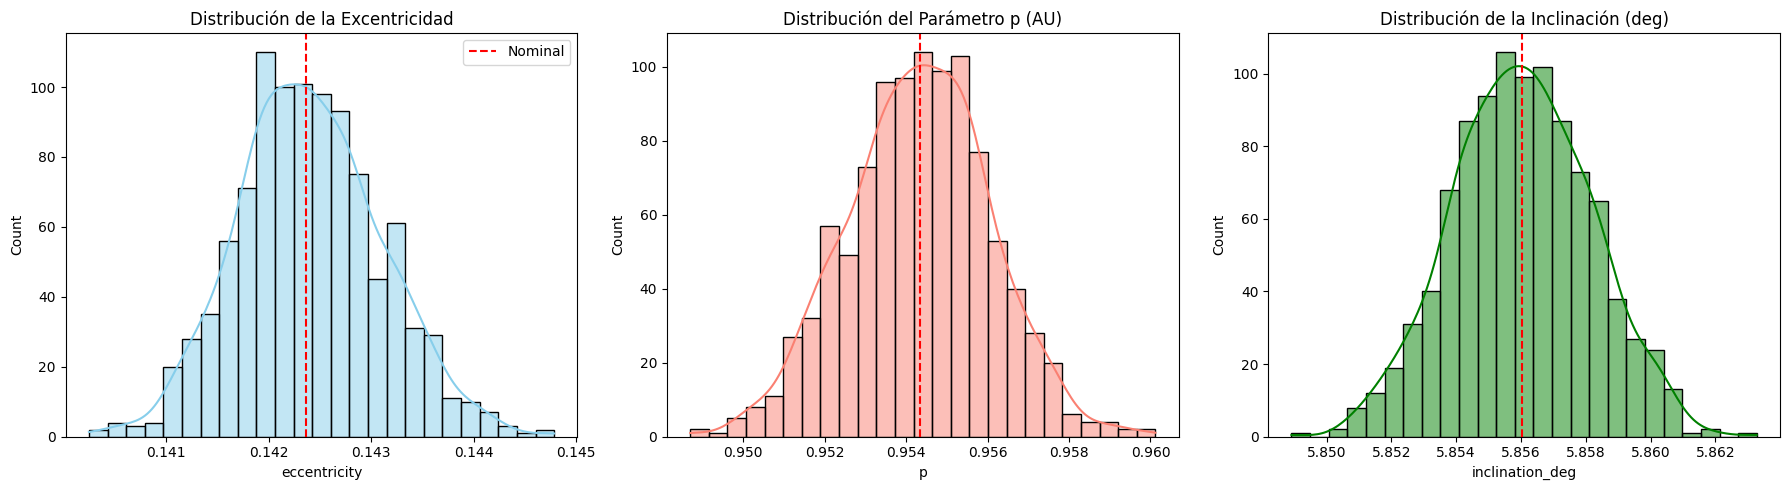

In [44]:
# Visualización de las distribuciones
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Histograma de Excentricidad
sns.histplot(df_mc['eccentricity'], kde=True, ax=axes[0], color='skyblue')
# elementos[1] es la excentricidad nominal
axes[0].axvline(elementos[1], color='red', linestyle='--', label='Nominal')
axes[0].set_title('Distribución de la Excentricidad')
axes[0].legend()

# 2. Histograma del Parámetro p (sustituye al semieje mayor en esta versión)
sns.histplot(df_mc['p'], kde=True, ax=axes[1], color='salmon')
# elementos[0] es el parámetro p nominal
axes[1].axvline(elementos[0], color='red', linestyle='--')
axes[1].set_title('Distribución del Parámetro p (AU)')

# 3. Histograma de la Inclinación
sns.histplot(df_mc['inclination_deg'], kde=True, ax=axes[2], color='green')
# elementos[2] es la inclinación en radianes, la convertimos a grados
axes[2].axvline(np.degrees(elementos[2]), color='red', linestyle='--')
axes[2].set_title('Distribución de la Inclinación (deg)')

plt.tight_layout()
plt.show()

In [45]:
# Resumen de dispersión
print(f"Incertidumbre en e: {df_mc['eccentricity'].std():.6f}")
print(f"Incertidumbre en i: {df_mc['inclination_deg'].std():.6f} grados")
print(f"Incertidumbre en p: {df_mc['p'].std():.6f} AU")

Incertidumbre en e: 0.000699
Incertidumbre en i: 0.002121 grados
Incertidumbre en p: 0.001750 AU


## Evolución temporal de la órbita
Con los elementos orbitales se puede propagar la posición del cuerpo en el tiempo. Esta parte
responde una pregunta distinta a la de la forma de la órbita: no basta con saber qué cónica es;
también necesitamos saber cómo se recorre.

### Partir de los elementos orbitales de la órbita inicial

In [46]:
def propagar(elementos_tuple, t_target, mu_val=mu):
    """
    Propaga la posición del objeto usando las leyes de Kepler.
    elementos_tuple: (p, e, i, Omega, omega, f)
    """
    p, e, i, Omega, omega, f0 = elementos_tuple
    t0 = df_target.iloc[idx_target]['t_jd_tdb']
    dt = t_target - t0

    # 1. Semieje mayor a partir de p y e
    a = p / (1 - e**2)
    n = np.sqrt(mu_val / abs(a)**3)

    # 2. Anomalía excéntrica inicial (E0) a partir de f0
    E0 = 2 * np.arctan(np.sqrt((1 - e)/(1 + e)) * np.tan(f0 / 2))
    M0 = E0 - e * np.sin(E0)

    # 3. Anomalía media al tiempo t_target
    M = M0 + n * dt

    # 4. Resolver ecuación de Kepler para E
    E = M
    for _ in range(10):
        E = E - (E - e * np.sin(E) - M) / (1 - e * np.cos(E))

    # 5. Anomalía verdadera final (f)
    f_t = 2 * np.arctan(np.sqrt((1 + e)/(1 - e)) * np.tan(E / 2))
    r_mag = a * (1 - e * np.cos(E))

    # 6. Posición en plano orbital y rotación
    # Re-utilizamos elementos_a_estado de pymcel con el nuevo f_t
    elementos_t = (p, e, i, Omega, omega, f_t)
    estado_t = pc.elementos_a_estado(mu_val, elementos_t)

    return estado_t[:3]

# Probar la función
t_futuro = df_target.iloc[idx_target]['t_jd_tdb'] + 10
r_futuro = propagar(elementos, t_futuro)
print(f"Posición predicha para JD {t_futuro}: {r_futuro} AU")

Posición predicha para JD 2459294.0: [-1.07205675  0.09816174  0.00780987] AU


La época 2459294 corresponde a la fecha de marzo de 2021 aparece porque los datos de observación que cargamos (observaciones_astrometricas.csv) corresponden a ese periodo específico.

Apophis tuvo un acercamiento notable a la Tierra el 5 de marzo de 2021 (a unos 0.11 UA). El código está diseñado para encontrar el punto de mínima distancia dentro del rango de tiempo de las observaciones suministradas. Si quisiéramos ver el famoso encuentro cercano de abril de 2029, necesitaríamos o bien observaciones de esa época (que aún no existen) o propagar la órbita actual durante varios años hacia el futuro, teniendo en cuenta que las perturbaciones planetarias harían que una simple propagación de Kepler pierda precisión en un intervalo tan largo.

## Máxima Proximidad a la Tierra

In [50]:
# Extraer la distancia Tierra-Objeto (rho) del dataset filtrado
distancias_tierra = df_target[['datetime_utc', 'rho_au']].copy()
# Conversión de AU a km
AU_KM = AU_M / 1000.0
distancias_tierra['Distancia (km)'] = distancias_tierra['rho_au'] * AU_KM
distancias_tierra.columns = ['Fecha UTC', 'Distancia (AU)', 'Distancia (km)']

print(f"Distancias calculadas para {target_object} respecto a la Tierra:")
display(distancias_tierra.head())

# Distancia mínima observada en este periodo
min_dist_au = df_target['rho_au'].min()
min_dist_km = min_dist_au * AU_KM
fecha_min = df_target.loc[df_target['rho_au'].idxmin(), 'datetime_utc']

print(f"\nLa distancia mínima observada fue de {min_dist_au:.4f} AU ({min_dist_km:,.0f} km) el {fecha_min}.")

Distancias calculadas para apophis respecto a la Tierra:


,Fecha UTC,Distancia (AU),Distancia (km)
72,2021-02-28 23:58:50.815,0.114000,1.705419e+07
73,2021-03-01 11:58:50.815,0.113745,1.701605e+07
74,2021-03-01 23:58:50.815,0.113517,1.698192e+07
75,2021-03-02 11:58:50.815,0.113316,1.695179e+07
76,2021-03-02 23:58:50.815,0.113141,1.692567e+07



La distancia mínima observada fue de 0.1127 AU (16,852,428 km) el 2021-03-05 23:58:50.815.


Estos valores fueron comparados con los expuestos en el Small-Body Database del JPL y coinciden exitosamente.